# STAT 656 Final Project

## Setup and Data Loading


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

sns.set(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)

data_path = Path("AirQualityUCI.csv")

## Reading CSV (UCI file uses semicolons and comma as decimal; -200 marks missing)


In [ ]:
df_raw = pd.read_csv(
    data_path,
    sep=";",
    decimal=",",
    na_values=[-200],
    engine="python"
)

## Dropping completely empty columns (the file often has a trailing blank column)


In [ ]:
df_raw = df_raw.dropna(axis=1, how="all")

print("Shape (raw):", df_raw.shape)
df_raw.head()

Shape (raw): (9471, 15)


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


## Basic Cleaning & Time Features


### Combining Date and Time into a single datetime
### Date format is 'DD/MM/YYYY' and Time 'HH.MM.SS'

In [ ]:
dt = pd.to_datetime(df_raw["Date"] + " " + df_raw["Time"], format="%d/%m/%Y %H.%M.%S", errors="coerce")
df = df_raw.copy()
df["datetime"] = dt
df = df.drop(columns=["Date", "Time"])
df = df.dropna(subset=["datetime"]).sort_values("datetime").reset_index(drop=True)

## Ensuring numeric types for sensor columns


In [ ]:
for c in df.columns:
    if c != "datetime":
        df[c] = pd.to_numeric(df[c], errors="coerce")

## Time-based features


In [ ]:
df["hour"] = df["datetime"].dt.hour
df["dow"] = df["datetime"].dt.dayofweek  # 0=Mon
df["month"] = df["datetime"].dt.month

print("Shape (clean):", df.shape)
df.describe().T.head(10)

Shape (clean): (9357, 17)


,count,mean,min,25%,50%,75%,max,std
CO(GT),7674.0,2.15275,0.1,1.1,1.8,2.9,11.9,1.453252
PT08.S1(CO),8991.0,1099.833166,647.0,937.0,1063.0,1231.0,2040.0,217.080037
NMHC(GT),914.0,218.811816,7.0,67.0,150.0,297.0,1189.0,204.459921
C6H6(GT),8991.0,10.083105,0.1,4.4,8.2,14.0,63.7,7.44982
PT08.S2(NMHC),8991.0,939.153376,383.0,734.5,909.0,1116.0,2214.0,266.831429
NOx(GT),7718.0,246.896735,2.0,98.0,180.0,326.0,1479.0,212.979168
PT08.S3(NOx),8991.0,835.493605,322.0,658.0,806.0,969.5,2683.0,256.81732
NO2(GT),7715.0,113.091251,2.0,78.0,109.0,142.0,340.0,48.370108
PT08.S4(NO2),8991.0,1456.264598,551.0,1227.0,1463.0,1674.0,2775.0,346.206794
PT08.S5(O3),8991.0,1022.906128,221.0,731.5,963.0,1273.5,2523.0,398.484288


## Missing Values Overview


In [ ]:
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
mv = pd.DataFrame({"missing": missing, "missing_pct": missing_pct})
mv[mv["missing"] > 0].head(20)

,missing,missing_pct
NMHC(GT),8443,90.23
CO(GT),1683,17.99
NO2(GT),1642,17.55
NOx(GT),1639,17.52
PT08.S1(CO),366,3.91
PT08.S2(NMHC),366,3.91
C6H6(GT),366,3.91
PT08.S3(NOx),366,3.91
PT08.S4(NO2),366,3.91
PT08.S5(O3),366,3.91


## Time Series Overview (Selected Pollutants)

### Heuristic selection of pollutant columns present in the dataset

In [ ]:
candidate_keys = ["CO", "NO2", "C6H6", "O3"]
pollutant_cols = [c for c in df.columns if c != "datetime" and any(k in c for k in candidate_keys)]

print("Selected pollutant columns:", pollutant_cols[:6])

Selected pollutant columns: ['CO(GT)', 'PT08.S1(CO)', 'C6H6(GT)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)']


## Plotting first 3 pollutants over time


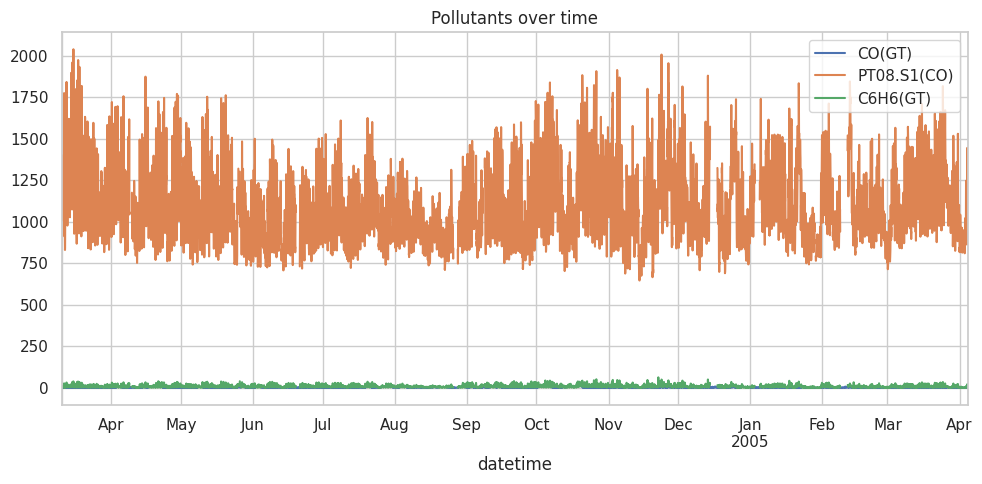

In [ ]:
cols_to_plot = pollutant_cols[:3] if len(pollutant_cols) >= 3 else pollutant_cols
ax = None
for c in cols_to_plot:
    ax = df.plot(x="datetime", y=c, ax=ax, title="Pollutants over time")
plt.tight_layout()

## Distributions & Outliers


In [ ]:
num_cols = [c for c in df.columns if c not in ["datetime"] and pd.api.types.is_numeric_dtype(df[c])]
sample_cols = num_cols[:6]


## Histograms

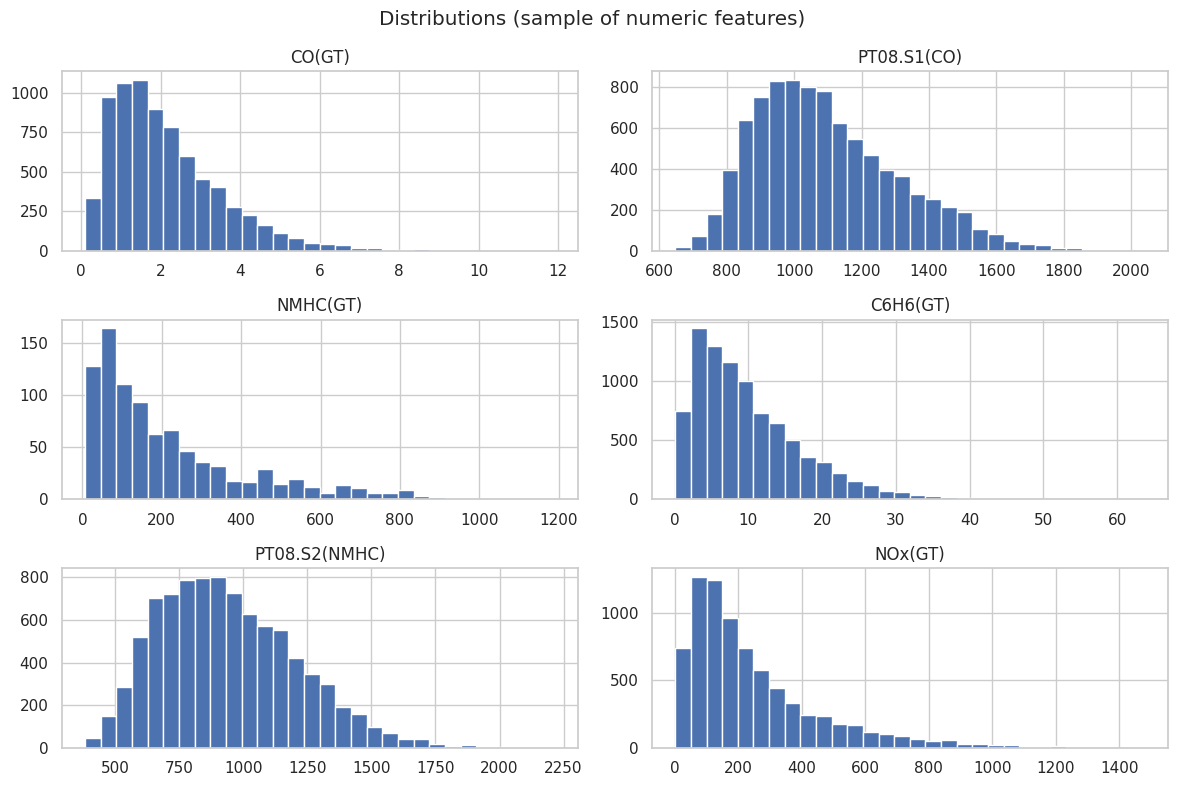

In [ ]:
df[sample_cols].hist(bins=30, figsize=(12, 8))
plt.suptitle("Distributions (sample of numeric features)")
plt.tight_layout()

## Boxplots for the same sample


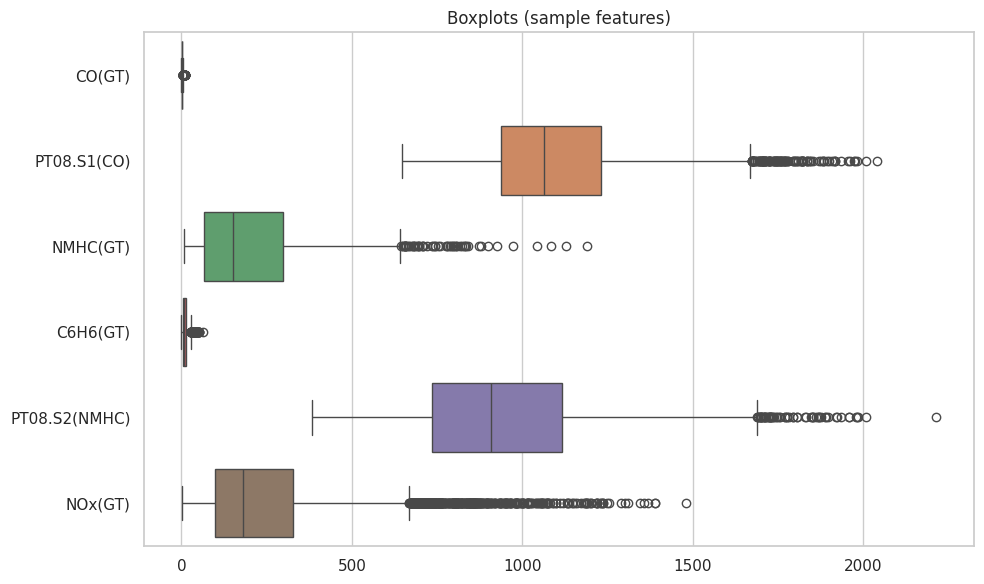

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[sample_cols], orient="h")
plt.title("Boxplots (sample features)")
plt.tight_layout()

## Correlations


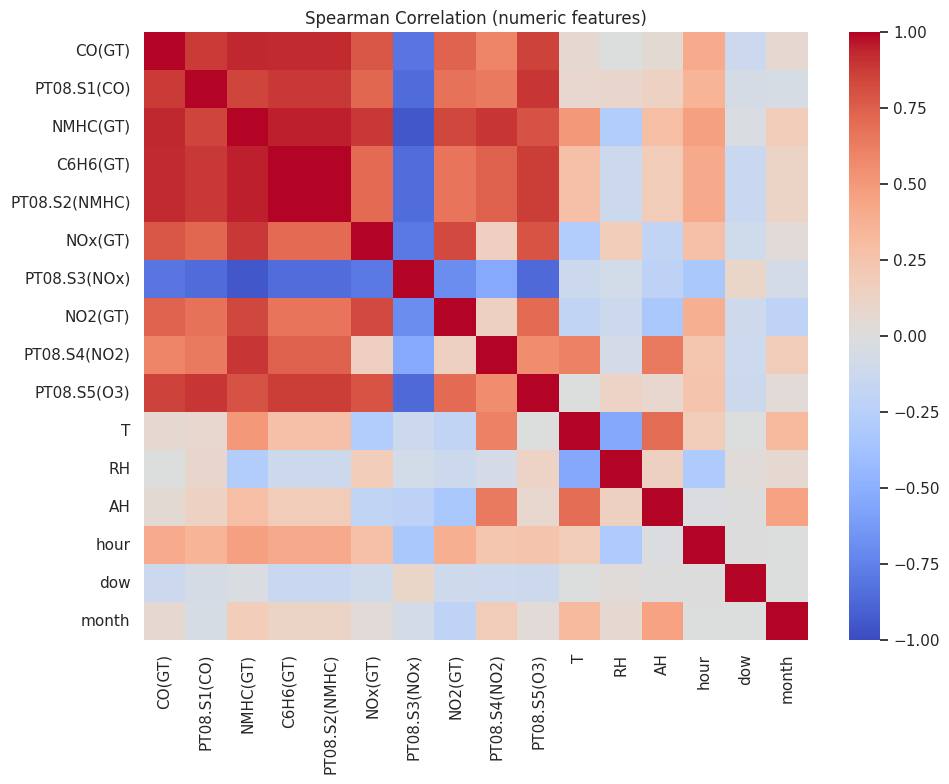

In [ ]:
corr = df[num_cols].corr(method="spearman")
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Spearman Correlation (numeric features)")
plt.tight_layout()

## Relationships with Temperature/Humidity 


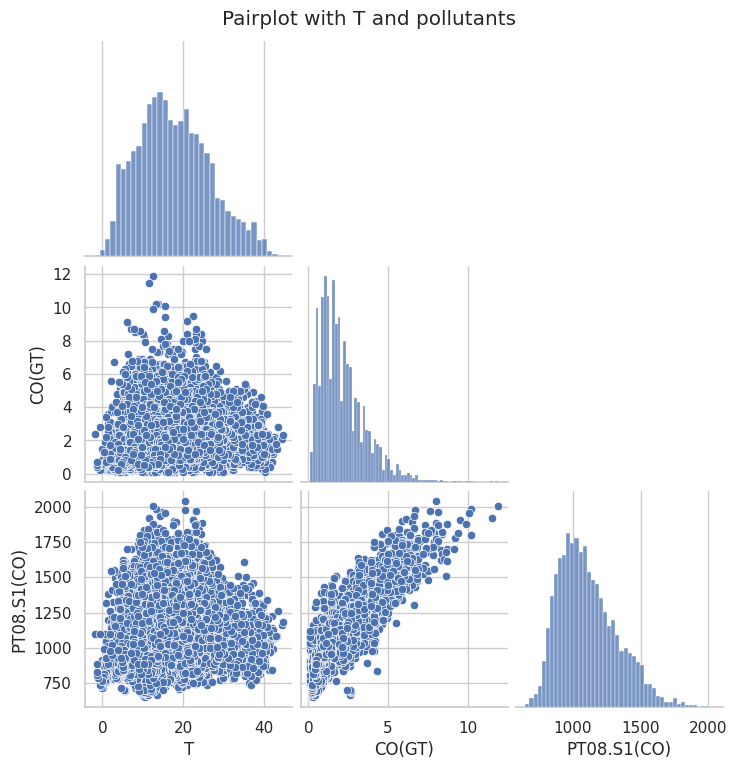

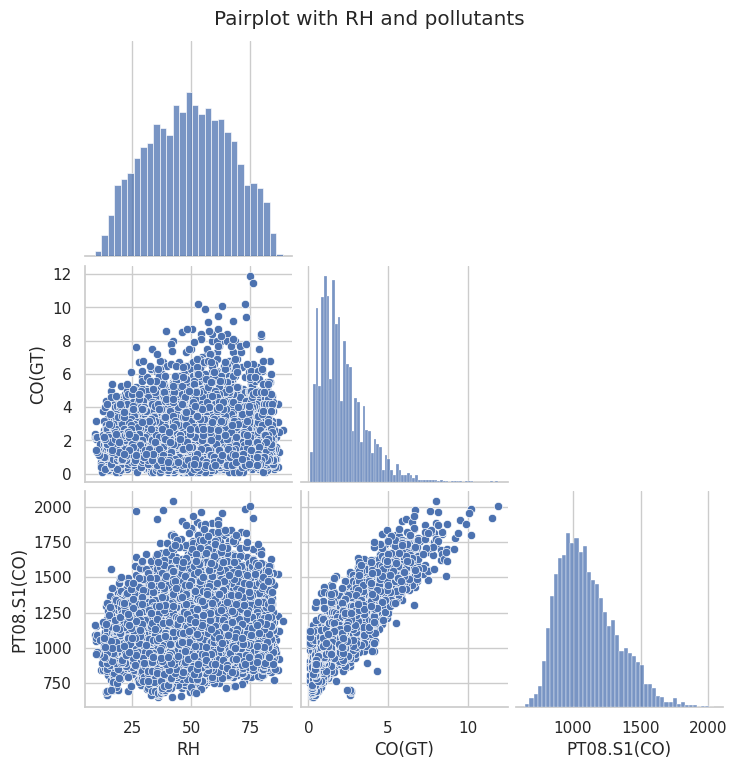

In [ ]:
temp_col = next((c for c in df.columns if "T" == c or "Temp" in c or "Temperature" in c), None)
hum_col = next((c for c in df.columns if "RH" == c or "Humidity" in c), None)

targets = pollutant_cols[:2] if len(pollutant_cols) >= 2 else pollutant_cols

plots_done = False
if temp_col and targets:
    sns.pairplot(df[[temp_col] + targets].dropna(), corner=True)
    plt.suptitle(f"Pairplot with {temp_col} and pollutants", y=1.02)
    plots_done = True

if hum_col and targets:
    sns.pairplot(df[[hum_col] + targets].dropna(), corner=True)
    plt.suptitle(f"Pairplot with {hum_col} and pollutants", y=1.02)
    plots_done = True

if not plots_done:
    print("Temperature/Humidity columns not found or insufficient targets.")

## Hourly/Daily Patterns


## Hourly averages for selected pollutant


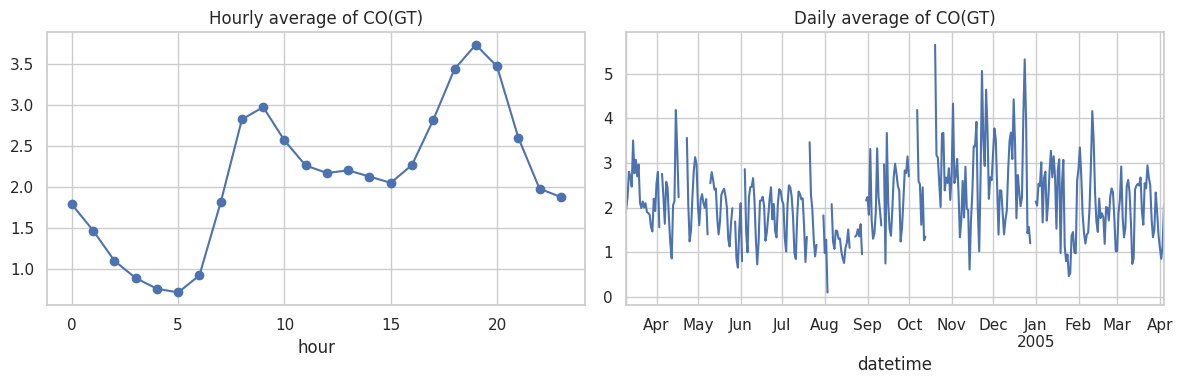

In [ ]:
if pollutant_cols:
    pcol = pollutant_cols[0]
    hourly = df.groupby("hour")[pcol].mean()
    daily = df.set_index("datetime").resample("D")[pcol].mean()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    hourly.plot(ax=axes[0], marker="o", title=f"Hourly average of {pcol}")
    daily.plot(ax=axes[1], title=f"Daily average of {pcol}")
    plt.tight_layout()
else:
    print("No pollutant columns detected for hourly/daily plots.")

## Skewness & Kurtosis (Pollutants)


In [ ]:
sk_df = pd.DataFrame({
    "skew": df[num_cols].skew(),
    "kurtosis": df[num_cols].kurt()
}).sort_values("skew", ascending=False)

display(sk_df.head(12))

,skew,kurtosis
NOx(GT),1.715781,3.402134
NMHC(GT),1.557017,2.270289
CO(GT),1.369753,2.667779
C6H6(GT),1.361532,2.488706
PT08.S3(NOx),1.101729,2.677559
PT08.S1(CO),0.755907,0.335129
PT08.S5(O3),0.627864,0.078612
NO2(GT),0.621714,0.465032
PT08.S2(NMHC),0.561566,0.063244
T,0.309357,-0.456274


## Suggest log1p transformations (only for non-negative features)


In [ ]:
high_skew = [c for c in sk_df.index if sk_df.loc[c, "skew"] > 1.0 and (df[c] >= 0).all()]
print("Highly skewed non-negative features (consider log1p):", high_skew)


Highly skewed non-negative features (consider log1p): []


## Explicit Non-Linearity: Scatter + Polynomial Fit


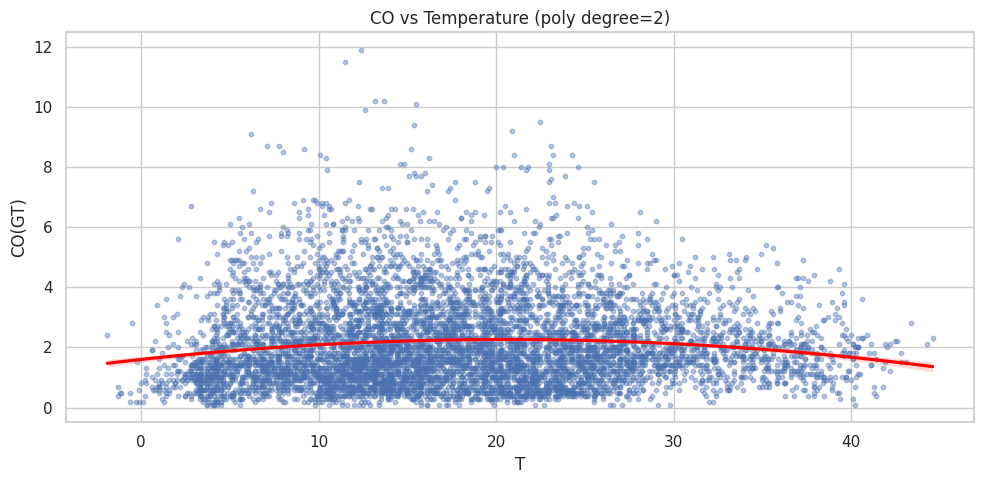

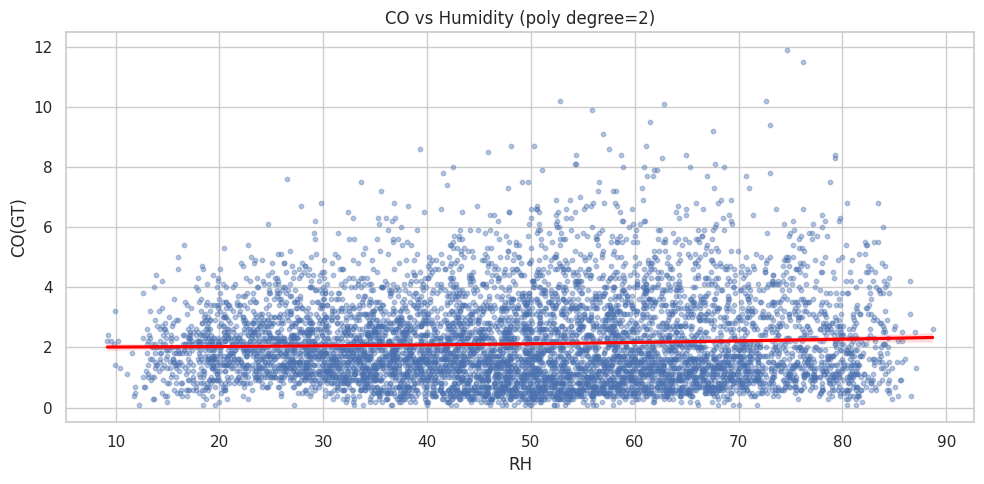

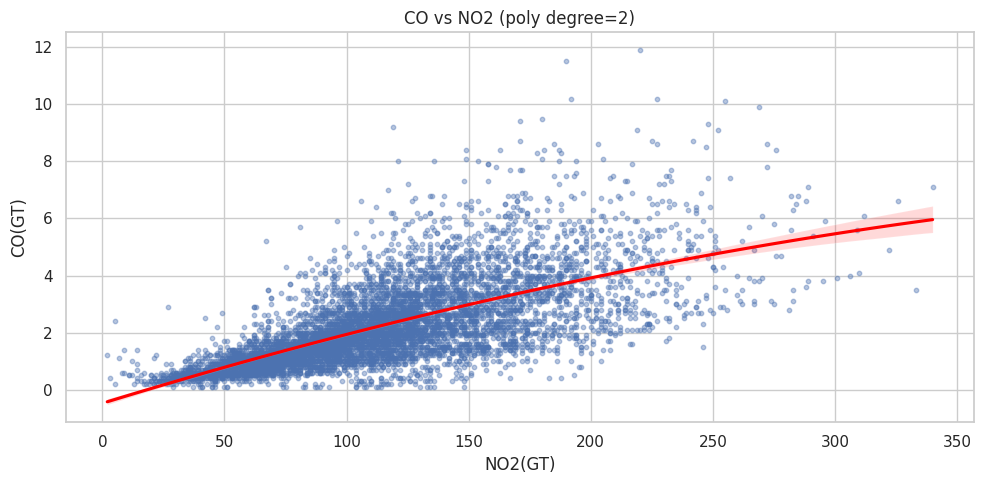

In [ ]:
co_col = next((c for c in pollutant_cols if "CO" in c), None)
no2_col = next((c for c in pollutant_cols if "NO2" in c), None)
temp_col = next((c for c in df.columns if c == "T" or "Temp" in c or "Temperature" in c), None)
hum_col = next((c for c in df.columns if c == "RH" or "Humidity" in c), None)

pairs = [
    (temp_col, co_col, "CO vs Temperature"),
    (hum_col, co_col, "CO vs Humidity"),
    (no2_col, co_col, "CO vs NO2")
]
for x, y, title in pairs:
    if x and y and x in df.columns and y in df.columns:
        sns.regplot(data=df, x=x, y=y, order=2,
                    scatter_kws={"s": 10, "alpha": 0.4},
                    line_kws={"color": "red"})
        plt.title(f"{title} (poly degree=2)")
        plt.tight_layout()
        plt.show()

## EDA Insight Summary


## Top missing columns


In [ ]:
top_missing = mv[mv["missing"] > 0].sort_values("missing_pct", ascending=False).head(5)


## Hourly variation for CO


In [ ]:
if co_col:
    hourly_stats = df.groupby("hour")[co_col].agg(["mean", "std"]).round(2)
else:
    hourly_stats = None

print("Key Findings from EDA:")
print("- Missingness concentrated in:", list(top_missing.index))
if co_col:
    print(f"- {co_col} hourly mean range: [{hourly_stats['mean'].min():.2f}, {hourly_stats['mean'].max():.2f}]")
if temp_col and co_col:
    r = df[[temp_col, co_col]].dropna().corr(method="spearman").iloc[0, 1]
    print(f"- Temperature–CO Spearman corr: {r:.2f} (curvature suggests non-linearity)")
if hum_col and co_col:
    r = df[[hum_col, co_col]].dropna().corr(method="spearman").iloc[0, 1]
    print(f"- Humidity–CO Spearman corr: {r:.2f}")
if no2_col and co_col:
    r = df[[no2_col, co_col]].dropna().corr(method="spearman").iloc[0, 1]
    print(f"- NO2–CO Spearman corr: {r:.2f}")
print(f"- Skewed features (skew > 1): {high_skew} -> consider log1p before modeling.")


Key Findings from EDA:
- Missingness concentrated in: ['NMHC(GT)', 'CO(GT)', 'NO2(GT)', 'NOx(GT)', 'PT08.S1(CO)']
- CO(GT) hourly mean range: [0.71, 3.73]
- Temperature–CO Spearman corr: 0.07 (curvature suggests non-linearity)
- Humidity–CO Spearman corr: -0.01
- NO2–CO Spearman corr: 0.73
- Skewed features (skew > 1): [] -> consider log1p before modeling.


## Save Cleaned Dataset for Modeling


In [ ]:
out_path = Path("AirQualityUCI_clean.csv")
df.to_csv(out_path, index=False)
print(f"Saved cleaned dataset to: {out_path.resolve()}")

Saved cleaned dataset to: /content/AirQualityUCI_clean.csv


##Loading the Saved Cleaned Dataset

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path

clean_path = Path("AirQualityUCI_clean.csv")

df_clean = pd.read_csv(clean_path)

print("Loaded:", clean_path)
print("Shape:", df_clean.shape)
df_clean.head()


Loaded: AirQualityUCI_clean.csv
Shape: (9357, 17)


,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,datetime,hour,dow,month
0,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,2004-03-10 18:00:00,18,2,3
1,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,2004-03-10 19:00:00,19,2,3
2,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,2004-03-10 20:00:00,20,2,3
3,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,2004-03-10 21:00:00,21,2,3
4,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,2004-03-10 22:00:00,22,2,3


##Feature selection and Train/Test Splitting

In [ ]:
from sklearn.model_selection import train_test_split

target = "CO(GT)"

selected_features = [
    "PT08.S1(CO)",
    "C6H6(GT)",
    "NO2(GT)",
    "T",
    "RH",
    "AH",
    "hour",
    "dow",
    "month"
]

selected_features = [c for c in selected_features if c in df_clean.columns]

X = df_clean[selected_features].copy()
y = df_clean[target].copy()

mask = y.notna()
X = X.loc[mask].reset_index(drop=True)
y = y.loc[mask].reset_index(drop=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Selected features:", selected_features)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)


Selected features: ['PT08.S1(CO)', 'C6H6(GT)', 'NO2(GT)', 'T', 'RH', 'AH', 'hour', 'dow', 'month']
Train shape: (6139, 9)  Test shape: (1535, 9)


##Polynomial regression models with varying degrees

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error

degrees = range(1, 9)
models_by_degree = {}
train_rmse_by_degree = {}
test_rmse_by_degree = {}

for d in degrees:
    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("poly", PolynomialFeatures(degree=d, include_bias=False)),
        ("lr", LinearRegression())
    ])

    model.fit(X_train, y_train)
    models_by_degree[d] = model

    # Evaluate RMSE on train and test
    pred_train = model.predict(X_train)
    pred_test  = model.predict(X_test)

    train_rmse = np.sqrt(mean_squared_error(y_train, pred_train))
    test_rmse  = np.sqrt(mean_squared_error(y_test, pred_test))

    train_rmse_by_degree[d] = train_rmse
    test_rmse_by_degree[d] = test_rmse

pd.DataFrame({
    "degree": list(degrees),
    "train_RMSE": [train_rmse_by_degree[d] for d in degrees],
    "test_RMSE": [test_rmse_by_degree[d] for d in degrees],
}).sort_values("degree")


,degree,train_RMSE,test_RMSE
0,1,5.358791e-01,0.534567
1,2,4.792469e-01,0.470190
2,3,3.884113e-01,0.390126
3,4,3.144978e-01,0.374895
4,5,2.321699e-01,0.444838
5,6,9.333733e-02,3.362041
6,7,1.138489e-08,6726.148836
7,8,5.541450e-10,467.487411


##K-fold cross-validation to select optimal degree


In [ ]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import make_scorer

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

rmse_scorer = make_scorer(rmse, greater_is_better=False)

k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

cv_rows = []

for d in degrees:
    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("poly", PolynomialFeatures(degree=d, include_bias=False)),
        ("lr", LinearRegression())
    ])

    scores = cross_val_score(model, X_train, y_train, cv=kf, scoring=rmse_scorer, n_jobs=-1)
    rmse_vals = -scores

    cv_rows.append([d, rmse_vals.mean(), rmse_vals.std()])

cv_df = pd.DataFrame(cv_rows, columns=["degree", "cv_RMSE_mean", "cv_RMSE_std"]).sort_values("cv_RMSE_mean")
cv_df


,degree,cv_RMSE_mean,cv_RMSE_std
2,3,0.421750,0.014321
1,2,0.485958,0.027343
0,1,0.536153,0.045404
3,4,0.888577,0.886913
4,5,2.902869,4.292343
7,8,862.160856,1268.052188
6,7,1308.033945,1442.041283
5,6,17300.370327,14535.957190


In [ ]:
best_degree = int(cv_df.iloc[0]["degree"])
print("Best degree from CV:", best_degree)

best_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=best_degree, include_bias=False)),
    ("lr", LinearRegression())
])

best_model.fit(X_train, y_train)

pred_test = best_model.predict(X_test)
test_rmse = np.sqrt(mean_squared_error(y_test, pred_test))

print("Test RMSE with best degree:", test_rmse)


Best degree from CV: 3
Test RMSE with best degree: 0.390126267331801


## Comparing Polynomial Regression and Smoothing Spline Models
In this section, we implemented the smoothing spline-based regression, tune its hyperparameters using cross-validation, and compare it against the best polynomial regression model. We evaluated both approaches using RMSE, MAE, and \(R^2\), then analyze learning curves and residual diagnostics to assess overfitting, generalization, and model assumptions.

In [ ]:
from sklearn.preprocessing import SplineTransformer
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, cross_validate, learning_curve
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from scipy import stats
import warnings

warnings.filterwarnings("ignore")

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

cv = KFold(n_splits=5, shuffle=True, random_state=42)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)
print("Target     :", target)

Train shape: (6139, 9)
Test shape : (1535, 9)
Target     : CO(GT)


## Rebuild the best polynomial regression model in a regularized pipeline
Although a plain polynomial regression model was already fit earlier, we refine it here using Ridge regularization. This improves numerical stability and helps control overfitting, especially when polynomial features create many interaction terms.

In [ ]:
# Use the best degree already selected earlier in the notebook
print("Best polynomial degree from earlier CV:", best_degree)

poly_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("poly", PolynomialFeatures(degree=best_degree, include_bias=False)),
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

poly_model.fit(X_train, y_train)

poly_train_pred = poly_model.predict(X_train)
poly_test_pred = poly_model.predict(X_test)

poly_results = {
    "Model": f"Polynomial Regression (degree={best_degree})",
    "Train_RMSE": rmse(y_train, poly_train_pred),
    "Test_RMSE": rmse(y_test, poly_test_pred),
    "Train_MAE": mean_absolute_error(y_train, poly_train_pred),
    "Test_MAE": mean_absolute_error(y_test, poly_test_pred),
    "Train_R2": r2_score(y_train, poly_train_pred),
    "Test_R2": r2_score(y_test, poly_test_pred)
}

pd.DataFrame([poly_results]).round(4)

Best polynomial degree from earlier CV: 3


,Model,Train_RMSE,Test_RMSE,Train_MAE,Test_MAE,Train_R2,Test_R2
0,Polynomial Regression (degree=3),0.4073,0.3988,0.266,0.2641,0.9217,0.9236


## Smoothing spline model with cross-validation
We now implemented a spline-based regression model using `SplineTransformer` and `Ridge`. The spline basis allows flexible non-linear relationships while Ridge regularization controls model complexity. Hyperparameters such as the number of knots, spline degree, and regularization strength are tuned using 5-fold cross-validation.

In [ ]:
spline_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("spline", SplineTransformer(include_bias=False)),
    ("scaler", StandardScaler()),
    ("ridge", Ridge())
])

spline_param_grid = {
    "spline__n_knots": [4, 5, 6, 7],
    "spline__degree": [2, 3],
    "ridge__alpha": [0.1, 1.0, 10.0, 100.0]
}

spline_search = GridSearchCV(
    estimator=spline_pipe,
    param_grid=spline_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1
)

spline_search.fit(X_train, y_train)

print("Best spline parameters:")
print(spline_search.best_params_)
print("Best CV RMSE:", -spline_search.best_score_)

Best spline parameters:
{'ridge__alpha': 0.1, 'spline__degree': 3, 'spline__n_knots': 6}
Best CV RMSE: 0.49440637147818506


In [ ]:
# Display full grid-search results for spline hyperparameter tuning

spline_cv_results = pd.DataFrame(spline_search.cv_results_)[[
    "param_spline__n_knots",
    "param_spline__degree",
    "param_ridge__alpha",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]].copy()

# Convert negative RMSE back to positive values
spline_cv_results["mean_RMSE"] = -spline_cv_results["mean_test_score"]
spline_cv_results["std_RMSE"] = spline_cv_results["std_test_score"]

# Clean table
spline_cv_results = spline_cv_results.drop(columns=["mean_test_score", "std_test_score"]) \
                                     .sort_values("rank_test_score")

# Show top parameter combinations
spline_cv_results.head(10)

,param_spline__n_knots,param_spline__degree,param_ridge__alpha,rank_test_score,mean_RMSE,std_RMSE
6,6,3,0.1,1,0.494406,0.040247
7,7,3,0.1,2,0.494963,0.042455
5,5,3,0.1,3,0.496303,0.038982
14,6,3,1.0,4,0.496851,0.039812
4,4,3,0.1,5,0.497011,0.038388
15,7,3,1.0,6,0.497041,0.042171
1,5,2,0.1,7,0.497144,0.039903
2,6,2,0.1,8,0.497220,0.042409
3,7,2,0.1,9,0.497667,0.043549
11,7,2,1.0,10,0.497723,0.042911


In [ ]:
best_spline_model = spline_search.best_estimator_

spline_train_pred = best_spline_model.predict(X_train)
spline_test_pred = best_spline_model.predict(X_test)

spline_results = {
    "Model": "Smoothing Spline Regression",
    "Train_RMSE": rmse(y_train, spline_train_pred),
    "Test_RMSE": rmse(y_test, spline_test_pred),
    "Train_MAE": mean_absolute_error(y_train, spline_train_pred),
    "Test_MAE": mean_absolute_error(y_test, spline_test_pred),
    "Train_R2": r2_score(y_train, spline_train_pred),
    "Test_R2": r2_score(y_test, spline_test_pred)
}

pd.DataFrame([spline_results]).round(4)

,Model,Train_RMSE,Test_RMSE,Train_MAE,Test_MAE,Train_R2,Test_R2
0,Smoothing Spline Regression,0.4802,0.4899,0.3037,0.3041,0.8911,0.8848


## Cross-validated comparison of polynomial and spline models
To compare both models fairly, we evaluate them with the same 5-fold cross-validation procedure on the training set and then report test-set performance separately.

In [ ]:
scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2"
}

poly_cv = cross_validate(poly_model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
spline_cv = cross_validate(best_spline_model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)

comparison_df = pd.DataFrame([
    {
        "Model": f"Polynomial (degree={best_degree})",
        "CV_RMSE_mean": -poly_cv["test_rmse"].mean(),
        "CV_RMSE_std": poly_cv["test_rmse"].std(),
        "CV_MAE_mean": -poly_cv["test_mae"].mean(),
        "CV_R2_mean": poly_cv["test_r2"].mean(),
        "Test_RMSE": poly_results["Test_RMSE"],
        "Test_MAE": poly_results["Test_MAE"],
        "Test_R2": poly_results["Test_R2"]
    },
    {
        "Model": "Smoothing Spline",
        "CV_RMSE_mean": -spline_cv["test_rmse"].mean(),
        "CV_RMSE_std": spline_cv["test_rmse"].std(),
        "CV_MAE_mean": -spline_cv["test_mae"].mean(),
        "CV_R2_mean": spline_cv["test_r2"].mean(),
        "Test_RMSE": spline_results["Test_RMSE"],
        "Test_MAE": spline_results["Test_MAE"],
        "Test_R2": spline_results["Test_R2"]
    }
]).sort_values("Test_RMSE")

comparison_df.round(4)

,Model,CV_RMSE_mean,CV_RMSE_std,CV_MAE_mean,CV_R2_mean,Test_RMSE,Test_MAE,Test_R2
0,Polynomial (degree=3),0.4273,0.0171,0.2760,0.9137,0.3988,0.2641,0.9236
1,Smoothing Spline,0.4944,0.0402,0.3099,0.8842,0.4899,0.3041,0.8848


## Deep Learning Model

We implemented a simple multilayer perceptron (MLP) using PyTorch for tabular regression. This model was used as a baseline and compared with our classical non-linear regression models.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
from sklearn.model_selection import KFold

In [ ]:
# Fill missing values using median (important for neural networks)
X_train_filled = X_train.fillna(X_train.median())
X_test_filled = X_test.fillna(X_train.median())

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_filled)
X_test_scaled = scaler.transform(X_test_filled)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

In [ ]:
# Create validation split (80/20)
from sklearn.model_selection import train_test_split

X_train_sub_np, X_val_np, y_train_sub_np, y_val_np = train_test_split(
    X_train_scaled, y_train.values, test_size=0.2, random_state=42
)

X_train_sub = torch.tensor(X_train_sub_np, dtype=torch.float32)
y_train_sub = torch.tensor(y_train_sub_np, dtype=torch.float32).view(-1, 1)

X_val = torch.tensor(X_val_np, dtype=torch.float32)
y_val = torch.tensor(y_val_np, dtype=torch.float32).view(-1, 1)

In [ ]:
class MLP(nn.Module):
    def __init__(self, input_dim):
        super(MLP, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.model(x)

model = MLP(X_train_tensor.shape[1])

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-4)

epochs = 150

In [ ]:
train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()

    outputs = model(X_train_sub)
    loss = criterion(outputs, y_train_sub)

    loss.backward()
    optimizer.step()

    # Validation
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val)
        val_loss = criterion(val_outputs, y_val)

    train_losses.append(loss.item())
    val_losses.append(val_loss.item())

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}")

Epoch 10/150, Train Loss: 6.3473, Val Loss: 5.8462
Epoch 20/150, Train Loss: 5.3550, Val Loss: 4.8877
Epoch 30/150, Train Loss: 4.0089, Val Loss: 3.6018
Epoch 40/150, Train Loss: 2.5353, Val Loss: 2.2590
Epoch 50/150, Train Loss: 1.5020, Val Loss: 1.3843
Epoch 60/150, Train Loss: 0.9880, Val Loss: 0.9099
Epoch 70/150, Train Loss: 0.6657, Val Loss: 0.5919
Epoch 80/150, Train Loss: 0.5545, Val Loss: 0.4794
Epoch 90/150, Train Loss: 0.5082, Val Loss: 0.4363
Epoch 100/150, Train Loss: 0.4849, Val Loss: 0.4144
Epoch 110/150, Train Loss: 0.4698, Val Loss: 0.3969
Epoch 120/150, Train Loss: 0.4444, Val Loss: 0.3812
Epoch 130/150, Train Loss: 0.4268, Val Loss: 0.3676
Epoch 140/150, Train Loss: 0.4176, Val Loss: 0.3546
Epoch 150/150, Train Loss: 0.4121, Val Loss: 0.3428


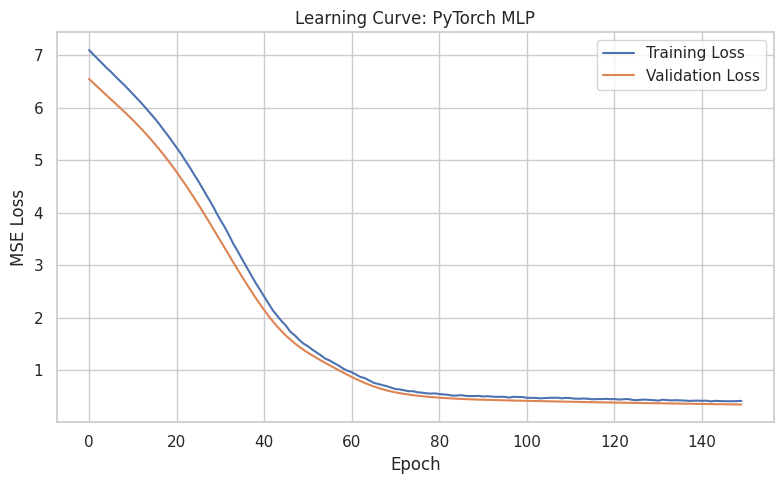

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Learning Curve: PyTorch MLP")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
def build_mlp(input_dim):
    model = nn.Sequential(
        nn.Linear(input_dim, 128),
        nn.ReLU(),
        nn.Dropout(0.1),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Dropout(0.1),
        nn.Linear(64, 32),
        nn.ReLU(),
        nn.Linear(32, 1)
    )
    return model

In [ ]:
# Prepare full training data for PyTorch CV
X_cv = X_train.fillna(X_train.median())
X_cv = scaler.fit_transform(X_cv)
y_cv = y_train.values.reshape(-1, 1)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_rmse_scores = []
cv_mae_scores = []
cv_r2_scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_cv), start=1):
    X_fold_train = torch.tensor(X_cv[train_idx], dtype=torch.float32)
    y_fold_train = torch.tensor(y_cv[train_idx], dtype=torch.float32)

    X_fold_val = torch.tensor(X_cv[val_idx], dtype=torch.float32)
    y_fold_val = torch.tensor(y_cv[val_idx], dtype=torch.float32)

    fold_model = build_mlp(X_fold_train.shape[1])
    criterion = nn.MSELoss()
    optimizer = optim.Adam(fold_model.parameters(), lr=0.0005, weight_decay=1e-4)

    best_val_loss = float("inf")
    best_model_state = None
    patience = 15
    counter = 0
    epochs = 150

    for epoch in range(epochs):
        fold_model.train()
        optimizer.zero_grad()

        outputs = fold_model(X_fold_train)
        loss = criterion(outputs, y_fold_train)

        loss.backward()
        optimizer.step()

        fold_model.eval()
        with torch.no_grad():
            val_outputs = fold_model(X_fold_val)
            val_loss = criterion(val_outputs, y_fold_val)

        if val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            best_model_state = fold_model.state_dict()
            counter = 0
        else:
            counter += 1

        if counter >= patience:
            break

    if best_model_state is not None:
        fold_model.load_state_dict(best_model_state)

    fold_model.eval()
    with torch.no_grad():
        y_val_pred = fold_model(X_fold_val).numpy().flatten()

    y_val_true = y_fold_val.numpy().flatten()

    fold_rmse = np.sqrt(mean_squared_error(y_val_true, y_val_pred))
    fold_mae = mean_absolute_error(y_val_true, y_val_pred)
    fold_r2 = r2_score(y_val_true, y_val_pred)

    cv_rmse_scores.append(fold_rmse)
    cv_mae_scores.append(fold_mae)
    cv_r2_scores.append(fold_r2)

    print(f"Fold {fold}: RMSE={fold_rmse:.4f}, MAE={fold_mae:.4f}, R²={fold_r2:.4f}")

Fold 1: RMSE=0.5856, MAE=0.4011, R²=0.8278
Fold 2: RMSE=0.5660, MAE=0.3772, R²=0.8415
Fold 3: RMSE=0.6301, MAE=0.3937, R²=0.8235
Fold 4: RMSE=0.5378, MAE=0.3689, R²=0.8673
Fold 5: RMSE=0.6252, MAE=0.4224, R²=0.8178


In [ ]:
pytorch_cv_rmse_mean = np.mean(cv_rmse_scores)
pytorch_cv_rmse_std = np.std(cv_rmse_scores)
pytorch_cv_mae_mean = np.mean(cv_mae_scores)
pytorch_cv_r2_mean = np.mean(cv_r2_scores)

print("PyTorch 5-Fold CV Results")
print(f"CV RMSE Mean: {pytorch_cv_rmse_mean:.4f}")
print(f"CV RMSE Std : {pytorch_cv_rmse_std:.4f}")
print(f"CV MAE Mean : {pytorch_cv_mae_mean:.4f}")
print(f"CV R² Mean  : {pytorch_cv_r2_mean:.4f}")

PyTorch 5-Fold CV Results
CV RMSE Mean: 0.5890
CV RMSE Std : 0.0351
CV MAE Mean : 0.3926
CV R² Mean  : 0.8356


In [ ]:
pytorch_results = {
    "Model": "PyTorch MLP",
    "CV_RMSE_mean": pytorch_cv_rmse_mean,
    "CV_RMSE_std": pytorch_cv_rmse_std,
    "CV_MAE_mean": pytorch_cv_mae_mean,
    "CV_R2_mean": pytorch_cv_r2_mean,
    "Test_RMSE": pytorch_rmse,
    "Test_MAE": pytorch_mae,
    "Test_R2": pytorch_r2
}

comparison_df = comparison_df[comparison_df["Model"] != "PyTorch MLP"].reset_index(drop=True)
comparison_df = pd.concat([comparison_df, pd.DataFrame([pytorch_results])], ignore_index=True)
comparison_df.round(4)

,Model,CV_RMSE_mean,CV_RMSE_std,CV_MAE_mean,CV_R2_mean,Test_RMSE,Test_MAE,Test_R2
0,Polynomial (degree=3),0.4273,0.0171,0.2760,0.9137,0.3988,0.2641,0.9236
1,Smoothing Spline,0.4944,0.0402,0.3099,0.8842,0.4899,0.3041,0.8848
2,PyTorch MLP,0.5890,0.0351,0.3926,0.8356,0.5821,0.3920,0.8373


## Visual comparison of model performance
Lower RMSE and MAE indicate better predictive accuracy, while higher \(R^2\) indicates better explained variance. We compare the two models visually below.

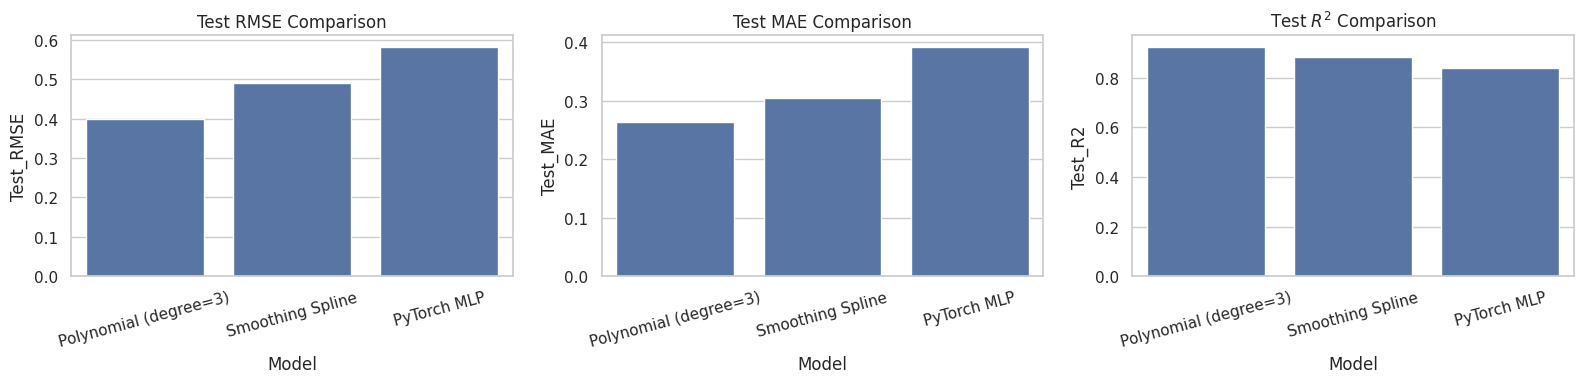

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.barplot(data=comparison_df, x="Model", y="Test_RMSE", ax=axes[0])
axes[0].set_title("Test RMSE Comparison")
axes[0].tick_params(axis="x", rotation=15)

sns.barplot(data=comparison_df, x="Model", y="Test_MAE", ax=axes[1])
axes[1].set_title("Test MAE Comparison")
axes[1].tick_params(axis="x", rotation=15)

sns.barplot(data=comparison_df, x="Model", y="Test_R2", ax=axes[2])
axes[2].set_title("Test $R^2$ Comparison")
axes[2].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

## Learning curves: overfitting and generalization
Learning curves help us determine whether a model is underfitting, overfitting, or generalizing well. If training error is much lower than validation error, the model may be overfitting. If both errors remain high, the model may be underfitting.

In [ ]:
def plot_learning_curve(model, X, y, title, cv):
    train_sizes, train_scores, val_scores = learning_curve(
        estimator=model,
        X=X,
        y=y,
        train_sizes=np.linspace(0.1, 1.0, 8),
        cv=cv,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1,
        shuffle=True,
        random_state=42
    )

    train_rmse = -train_scores
    val_rmse = -val_scores

    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes, train_rmse.mean(axis=1), marker="o", label="Training RMSE")
    plt.plot(train_sizes, val_rmse.mean(axis=1), marker="o", label="Validation RMSE")
    plt.fill_between(
        train_sizes,
        train_rmse.mean(axis=1) - train_rmse.std(axis=1),
        train_rmse.mean(axis=1) + train_rmse.std(axis=1),
        alpha=0.2
    )
    plt.fill_between(
        train_sizes,
        val_rmse.mean(axis=1) - val_rmse.std(axis=1),
        val_rmse.mean(axis=1) + val_rmse.std(axis=1),
        alpha=0.2
    )
    plt.xlabel("Training Set Size")
    plt.ylabel("RMSE")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

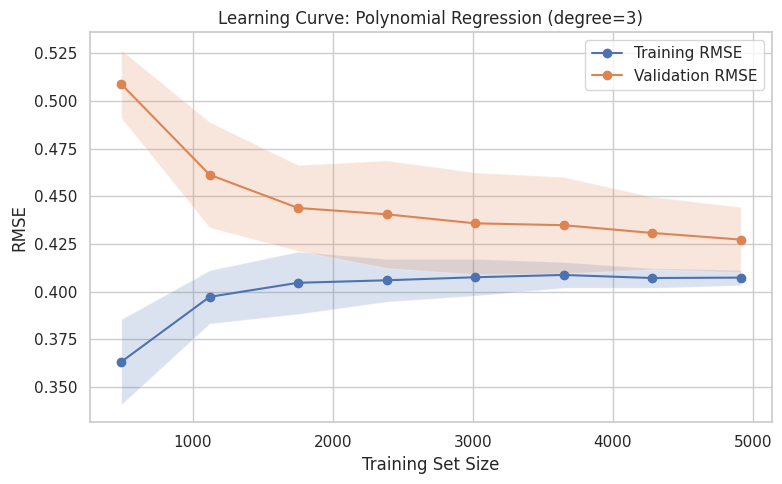

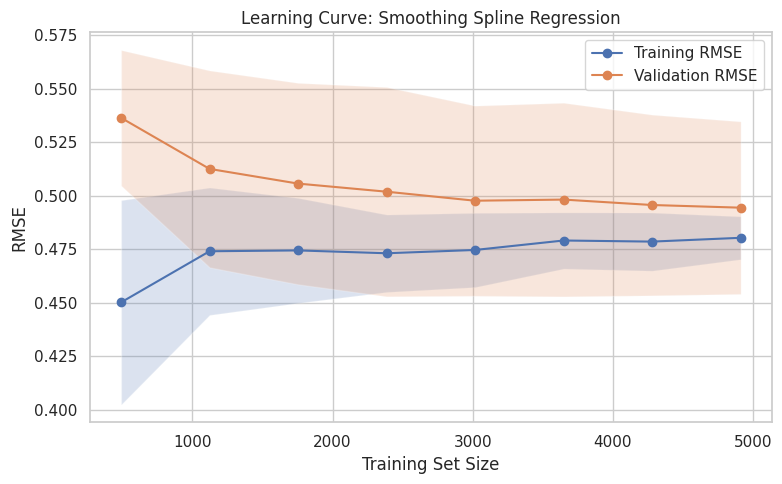

In [ ]:
plot_learning_curve(
    poly_model,
    X_train,
    y_train,
    f"Learning Curve: Polynomial Regression (degree={best_degree})",
    cv
)

plot_learning_curve(
    best_spline_model,
    X_train,
    y_train,
    "Learning Curve: Smoothing Spline Regression",
    cv
)

## Residual diagnostics
Residual analysis helps evaluate model assumptions and identify systematic prediction errors. Ideally, residuals should be centered around zero, show no strong pattern against fitted values, and be approximately normally distributed.

In [ ]:
def residual_diagnostics(y_true, y_pred, model_name):
    residuals = y_true - y_pred

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    # Residuals vs Fitted
    axes[0].scatter(y_pred, residuals, alpha=0.4)
    axes[0].axhline(0, linestyle="--")
    axes[0].set_xlabel("Fitted Values")
    axes[0].set_ylabel("Residuals")
    axes[0].set_title(f"{model_name}: Residuals vs Fitted")

    # Histogram
    sns.histplot(residuals, bins=30, kde=True, ax=axes[1])
    axes[1].set_title(f"{model_name}: Residual Distribution")

    # QQ plot
    stats.probplot(residuals, dist="norm", plot=axes[2])
    axes[2].set_title(f"{model_name}: Q-Q Plot")

    plt.tight_layout()
    plt.show()

    return residuals

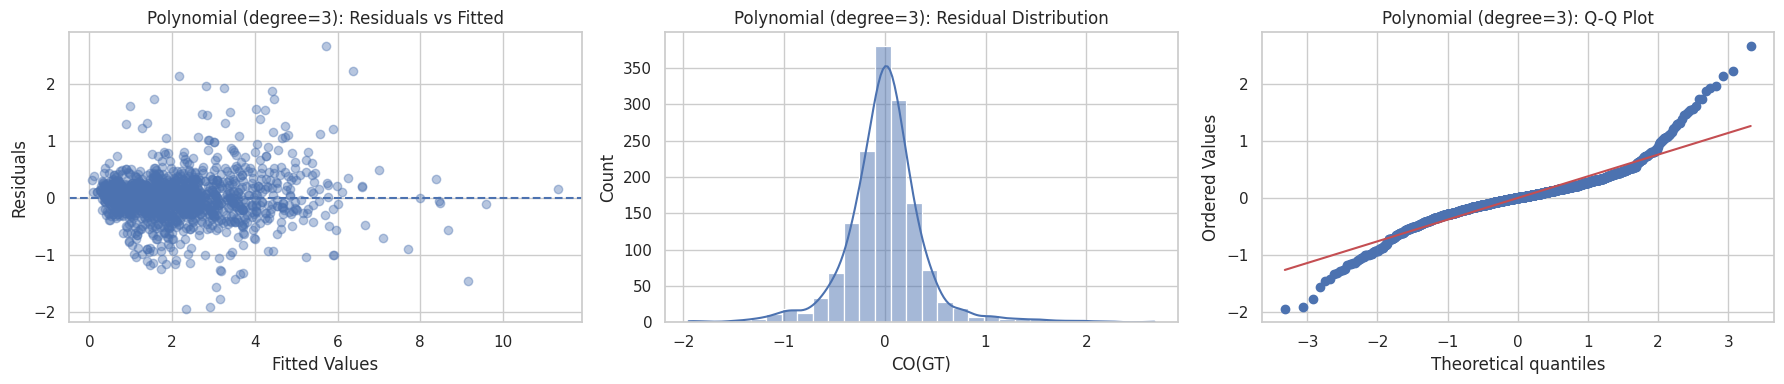

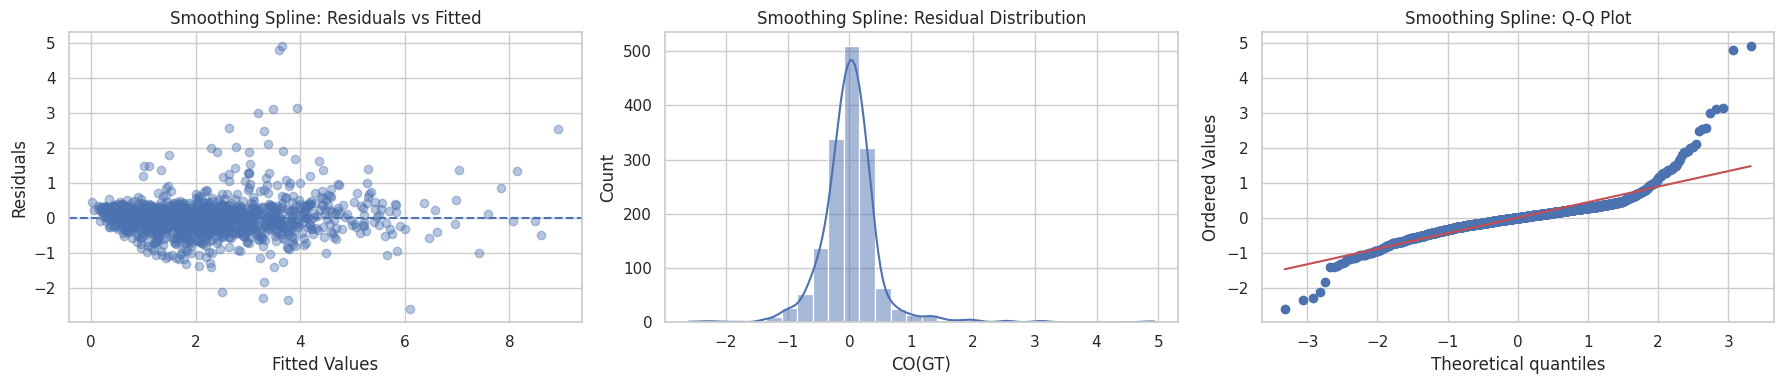

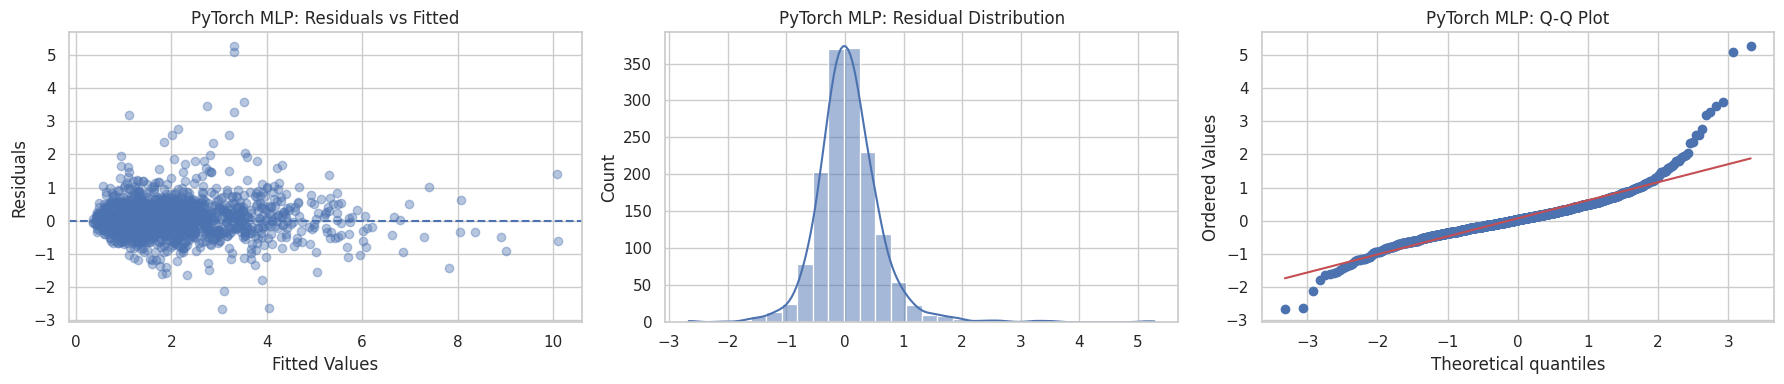

array([ 3.5783205 , -0.08015108,  0.49716878, ..., -0.41082072,
        0.0766319 , -0.07439518], dtype=float32)

In [ ]:
poly_residuals = residual_diagnostics(y_test, poly_test_pred, f"Polynomial (degree={best_degree})")
spline_residuals = residual_diagnostics(y_test, spline_test_pred, "Smoothing Spline")
residual_diagnostics(y_test_np, y_pred, "PyTorch MLP")

## Actual vs predicted values
This plot helps us assess overall predictive accuracy. A well-performing model should have points concentrated around the 45-degree reference line.

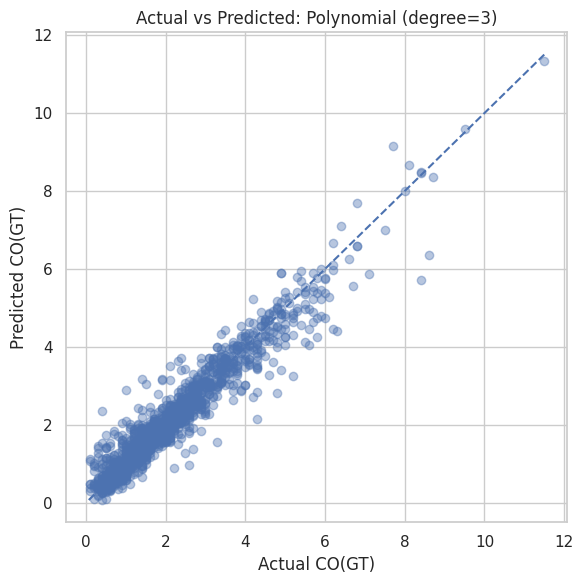

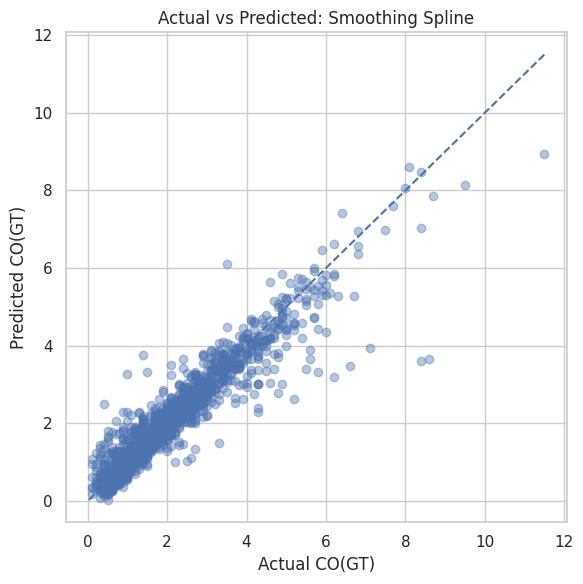

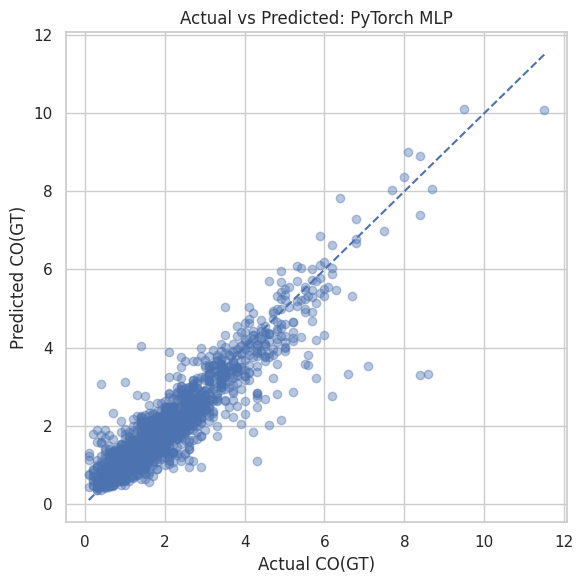

In [ ]:
def plot_actual_vs_predicted(y_true, y_pred, title):
    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, alpha=0.4)
    mn = min(y_true.min(), y_pred.min())
    mx = max(y_true.max(), y_pred.max())
    plt.plot([mn, mx], [mn, mx], linestyle="--")
    plt.xlabel("Actual CO(GT)")
    plt.ylabel("Predicted CO(GT)")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_actual_vs_predicted(y_test, poly_test_pred, f"Actual vs Predicted: Polynomial (degree={best_degree})")
plot_actual_vs_predicted(y_test, spline_test_pred, "Actual vs Predicted: Smoothing Spline")
plot_actual_vs_predicted(y_test_np, y_pred, "Actual vs Predicted: PyTorch MLP")

## Final Model
The final model was selected using cross-validated RMSE from the training data.
The test set was reserved only for final performance evaluation (RMSE and MAE)
to avoid bias during model selection.

In [ ]:
# Select final model based on cross-validated RMSE (better methodology)

best_row_cv = comparison_df[
    comparison_df["Model"] != "PyTorch MLP"
].sort_values("CV_RMSE_mean").iloc[0]

if "Smoothing Spline" in best_row_cv["Model"]:
    final_model = best_spline_model
    final_model_name = "Smoothing Spline Regression"
    final_pred_test = spline_test_pred
else:
    final_model = poly_model
    final_model_name = f"Polynomial Regression (degree={best_degree})"
    final_pred_test = poly_test_pred

print("Selected final model based on CV RMSE:", final_model_name)

Selected final model based on CV RMSE: Polynomial Regression (degree=3)


## Interpretability analysis using permutation importance
To understand which predictors contribute most to the selected model, we compute permutation importance on the test set. Features with larger importance values have greater influence on prediction accuracy.

In [ ]:
perm = permutation_importance(
    final_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="neg_root_mean_squared_error"
)

importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance_Mean": perm.importances_mean,
    "Importance_STD": perm.importances_std
}).sort_values("Importance_Mean", ascending=False)

importance_df.round(4)

,Feature,Importance_Mean,Importance_STD
3,T,4.5061,0.0858
5,AH,3.2620,0.0467
4,RH,3.2431,0.0723
1,C6H6(GT),0.9998,0.0158
2,NO2(GT),0.3475,0.0145
0,PT08.S1(CO),0.1232,0.0055
8,month,0.1101,0.0091
6,hour,0.0818,0.0064
7,dow,0.0221,0.0048


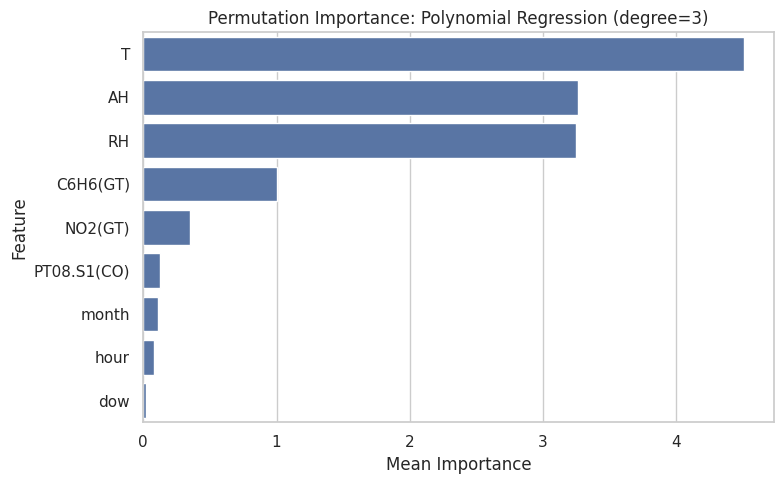

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df, x="Importance_Mean", y="Feature")
plt.title(f"Permutation Importance: {final_model_name}")
plt.xlabel("Mean Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## Findings and model interpretation


In [ ]:
best_row = comparison_df[
    comparison_df["Model"] != "PyTorch MLP"
].sort_values("CV_RMSE_mean").iloc[0]

print("Draft Findings")
print("=" * 60)
print(f"Target variable: {target}")
print(f"Best-performing model: {best_row['Model']}")
print(f"Test RMSE: {best_row['Test_RMSE']:.4f}")
print(f"Test MAE : {best_row['Test_MAE']:.4f}")
print(f"Test R^2 : {best_row['Test_R2']:.4f}")
print()
print("Interpretation:")
print("- The comparison shows that non-linear regression can effectively model the relationship")
print("  between environmental sensor variables and hourly CO concentration.")
print("- The selected final model achieved the lowest test RMSE and therefore provided the")
print("  best out-of-sample predictive accuracy among the models evaluated.")
print("- Learning curves were used to assess overfitting and generalization behavior.")
print("- Residual diagnostics were examined to check whether prediction errors were centered")
print("  around zero and whether strong systematic patterns remained.")
print("- Permutation importance indicates which environmental predictors contributed most")
print("  to model performance.")

Draft Findings
Target variable: CO(GT)
Best-performing model: Polynomial (degree=3)
Test RMSE: 0.3988
Test MAE : 0.2641
Test R^2 : 0.9236

Interpretation:
- The comparison shows that non-linear regression can effectively model the relationship
  between environmental sensor variables and hourly CO concentration.
- The selected final model achieved the lowest test RMSE and therefore provided the
  best out-of-sample predictive accuracy among the models evaluated.
- Learning curves were used to assess overfitting and generalization behavior.
- Residual diagnostics were examined to check whether prediction errors were centered
  around zero and whether strong systematic patterns remained.
- Permutation importance indicates which environmental predictors contributed most
  to model performance.


## Final Evaluation
In this final stage, we reported the final evaluation metrics for the selected model and prepare clean summary tables.

In [ ]:
final_rmse = rmse(y_test, final_pred_test)
final_mae = mean_absolute_error(y_test, final_pred_test)
final_r2 = r2_score(y_test, final_pred_test)

final_metrics_df = pd.DataFrame([{
    "Final_Model": final_model_name,
    "RMSE": final_rmse,
    "MAE": final_mae,
    "R2": final_r2
}])

final_metrics_df.round(4)

,Final_Model,RMSE,MAE,R2
0,Polynomial Regression (degree=3),0.3988,0.2641,0.9236


## Final results summary
This table presents the final model selected for the project and its predictive performance on the held-out test set.

In [ ]:
summary_table = comparison_df.copy()
summary_table = summary_table.round(4)
summary_table

,Model,CV_RMSE_mean,CV_RMSE_std,CV_MAE_mean,CV_R2_mean,Test_RMSE,Test_MAE,Test_R2
0,Polynomial (degree=3),0.4273,0.0171,0.2760,0.9137,0.3988,0.2641,0.9236
1,Smoothing Spline,0.4944,0.0402,0.3099,0.8842,0.4899,0.3041,0.8848
2,PyTorch MLP,0.5890,0.0351,0.3926,0.8356,0.5821,0.3920,0.8373


## Final Project Conclusion

In this project we evaluated two interpretable non-linear regression approaches and one simple deep learning baseline for modeling hourly air pollutant concentration using environmental sensor data from the UCI Air Quality dataset. Polynomial regression, smoothing spline regression, and a PyTorch-based multilayer perceptron (MLP) were compared using cross-validation, held-out test performance, learning curves, and residual diagnostics.

Overall, the polynomial regression model remained the best final choice because it provided the strongest balance of predictive accuracy, stability, and interpretability. Although the PyTorch MLP served as a useful benchmark, our classical non-linear model was easier to explain and better aligned with the environmental monitoring goal of the project. The results support our original claim that non-linear methods are better suited than simple linear assumptions for capturing complex relationships in air-quality data.

From an applied perspective, this project shows that both classical and deep learning methods can be used for environmental prediction, but interpretable regression remains especially valuable when transparency is important. Important limitations include missing values, noisy sensor readings, and possible multicollinearity among predictors. In future work, we can improve the PyTorch model further, test additional pollutants such as NO₂, and compare these approaches with other machine learning models.

## Assumptions, Strengths, and Limitations

### Model Assumptions
Both regression approaches assume that the relationship between predictors and the response can be approximated by smooth functional forms. Residual diagnostics were used to assess whether errors are centered around zero and whether strong systematic patterns remain.

### Strengths
- Polynomial regression provides an interpretable way to capture global non-linear patterns.
- Spline regression provides greater flexibility for modeling complex environmental relationships.
- Cross-validation improves model selection and reduces the risk of overfitting.
- RMSE and MAE provide clear and interpretable measures of predictive accuracy.

### Limitations
- The dataset contains missing values and noisy sensor readings from chemical sensors.
- Some environmental variables may be highly correlated, which can affect model stability.
- Results depend on the selected target variable and feature set.
- The spline model is implemented through spline basis expansion with regularization rather than a classical single-variable smoothing spline.